In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Let's load the cleaned data (cleaned by Ben, Katherine and Julian)

In [2]:
df = pd.read_csv('PUDF_base1_1q2019_cleaned.csv')

In [3]:
df.head(5)

,RECORD_ID,DISCHARGE,THCIC_ID,TYPE_OF_ADMISSION,SOURCE_OF_ADMISSION,PAT_STATE,PAT_ZIP,PAT_COUNTRY,PAT_COUNTY,PUBLIC_HEALTH_REGION,...,CODE_16,CODE_17,CODE_18,CODE_19,CODE_20,CODE_21,CODE_22,PAT_RURAL,PROVIDER_ZIP,PROVIDER_RURAL
0,120190000375,2019Q1,703003,3.0,2,TX,78418,US,355.0,11.0,...,0,0,0,0,0,0,0,0,78413,0
1,120190000376,2019Q1,703003,1.0,1,TX,78335,US,409.0,11.0,...,0,0,1,0,0,0,0,0,78413,0
2,120190000377,2019Q1,703003,3.0,2,TX,78336,US,409.0,11.0,...,0,0,0,0,0,0,0,0,78413,0
3,120190000378,2019Q1,703003,3.0,2,TX,78411,US,355.0,11.0,...,0,0,0,0,0,0,0,0,78413,0
4,120190000379,2019Q1,703003,3.0,2,TX,78414,US,355.0,11.0,...,0,0,0,0,0,0,0,0,78413,0


In [4]:
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 655221 entries, 0 to 655220
Data columns (total 44 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   RECORD_ID             655221 non-null  int64  
 1   DISCHARGE             655221 non-null  str    
 2   THCIC_ID              655221 non-null  int64  
 3   TYPE_OF_ADMISSION     655221 non-null  float64
 4   SOURCE_OF_ADMISSION   655221 non-null  str    
 5   PAT_STATE             655221 non-null  str    
 6   PAT_ZIP               655221 non-null  int64  
 7   PAT_COUNTRY           655221 non-null  str    
 8   PAT_COUNTY            655221 non-null  float64
 9   PUBLIC_HEALTH_REGION  655221 non-null  float64
 10  PAT_STATUS            655221 non-null  int64  
 11  SEX_CODE              655221 non-null  str    
 12  RACE                  655221 non-null  int64  
 13  ETHNICITY             655221 non-null  int64  
 14  ADMIT_WEEKDAY         655221 non-null  float64
 15  LENGTH_OF_S

Index(['RECORD_ID', 'DISCHARGE', 'THCIC_ID', 'TYPE_OF_ADMISSION',
       'SOURCE_OF_ADMISSION', 'PAT_STATE', 'PAT_ZIP', 'PAT_COUNTRY',
       'PAT_COUNTY', 'PUBLIC_HEALTH_REGION', 'PAT_STATUS', 'SEX_CODE', 'RACE',
       'ETHNICITY', 'ADMIT_WEEKDAY', 'LENGTH_OF_STAY', 'PAT_AGE',
       'EMERGENCY_DEPT_FLAG', 'DIAG_CODES_OA', 'CODE_1', 'CODE_2', 'CODE_3',
       'CODE_4', 'CODE_5', 'CODE_6', 'CODE_7', 'CODE_8', 'CODE_9', 'CODE_10',
       'CODE_11', 'CODE_12', 'CODE_13', 'CODE_14', 'CODE_15', 'CODE_16',
       'CODE_17', 'CODE_18', 'CODE_19', 'CODE_20', 'CODE_21', 'CODE_22',
       'PAT_RURAL', 'PROVIDER_ZIP', 'PROVIDER_RURAL'],
      dtype='str')

In [5]:
df['ADMIT_WEEKDAY'] = df['ADMIT_WEEKDAY'].astype('int')
df['TYPE_OF_ADMISSION'] = df['TYPE_OF_ADMISSION'].astype('int')
df['PUBLIC_HEALTH_REGION'] = df['PUBLIC_HEALTH_REGION'].astype('int')
df['LENGTH_OF_STAY'] = df['LENGTH_OF_STAY'].astype('int')


In [6]:
df['TYPE_OF_ADMISSION'].unique()

array([3, 1, 2, 4, 9, 5])

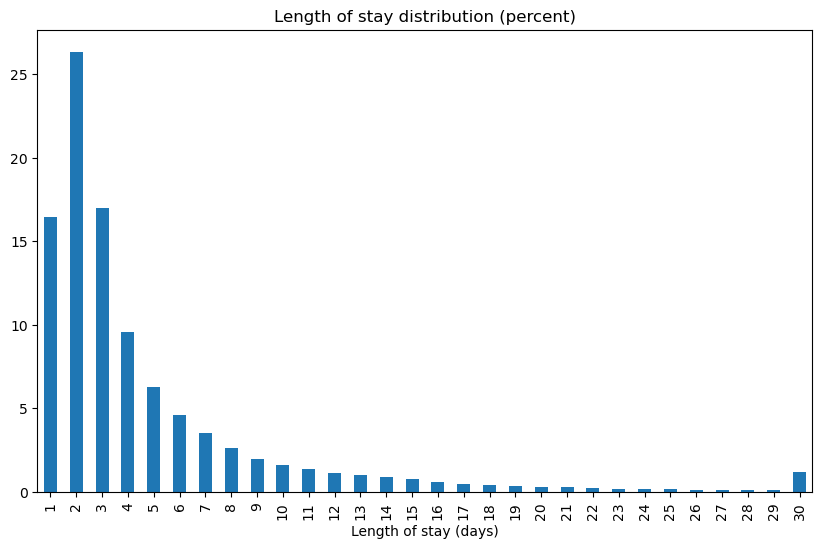

In [7]:
(df['LENGTH_OF_STAY'].clip(lower=0, upper=30).value_counts(normalize=True)*100).sort_index().plot(kind='bar', title='Length of stay distribution (percent)', figsize=(10, 6))
plt.xlabel('Length of stay (days)')
plt.show()

We compute the distance between the patient and the provider from their zip codes.

In [8]:
import pgeocode

dist = pgeocode.GeoDistance('us')

df['PAT_ZIP'] = df['PAT_ZIP'].astype(str)
df['PROVIDER_ZIP'] = df['PROVIDER_ZIP'].astype(str)

df['PAT2PROV_DISTANCE'] = dist.query_postal_code(
    df['PAT_ZIP'].values, 
    df['PROVIDER_ZIP'].values
)

df['PAT_ZIP'] = df['PAT_ZIP'].astype(int)
df['PROVIDER_ZIP'] = df['PROVIDER_ZIP'].astype(int)


## Distribution of the distance between patients and their medical providers

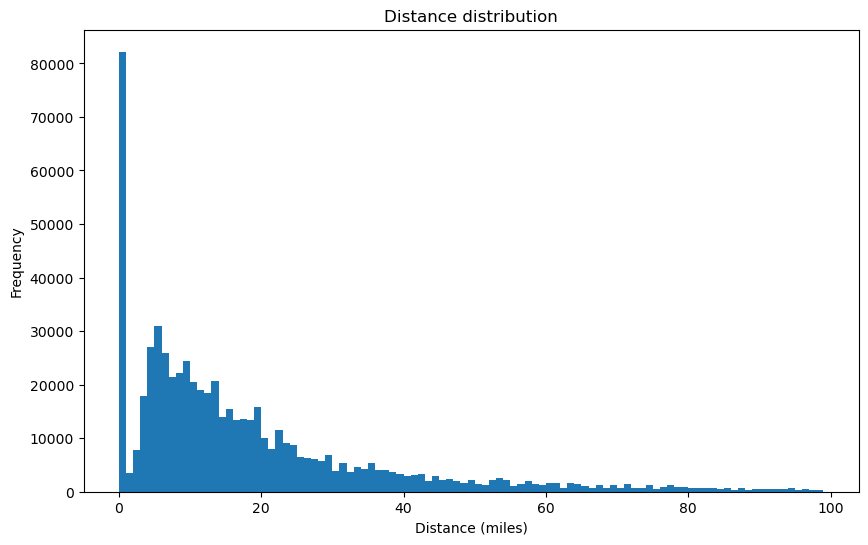

In [9]:
# (df['PAT2PROV_DISTANCE'].clip(lower=0, upper=500).value_counts(normalize=True)*100).sort_index().plot(kind='bar', title='Distance distribution (percent)', figsize=(10, 6))
ax = df['PAT2PROV_DISTANCE'].clip(lower=0, upper=1000).plot(kind='hist', title='Distance distribution', bins=np.arange(0, 100, 1), figsize=(10, 6), density=False)
ax.set_xlabel('Distance (miles)')

plt.show()

## Distribution of admissions by week day (1 to 7)

Admissions on weekends are lower.

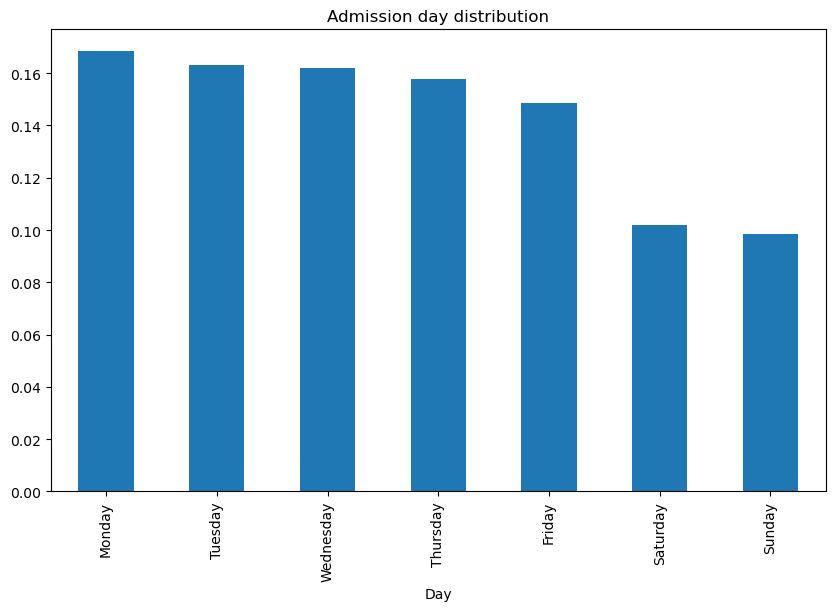

In [10]:
df['ADMIT_WEEKDAY'] = df['ADMIT_WEEKDAY'].astype('int')
ax = df['ADMIT_WEEKDAY'].value_counts(normalize=True)\
    .rename({1:'Monday', 2:'Tuesday', 3:'Wednesday', 4:'Thursday', 5:'Friday', 6:'Saturday', 7:'Sunday'})\
    .plot(kind='bar', title='Admission day distribution',figsize=(10, 6))
ax.set_xlabel('Day')

plt.show()


In [11]:
df['ADMIT_WEEKDAY'].value_counts()

ADMIT_WEEKDAY
1    110319
2    106861
3    106124
4    103309
5     97271
6     66822
7     64515
Name: count, dtype: int64

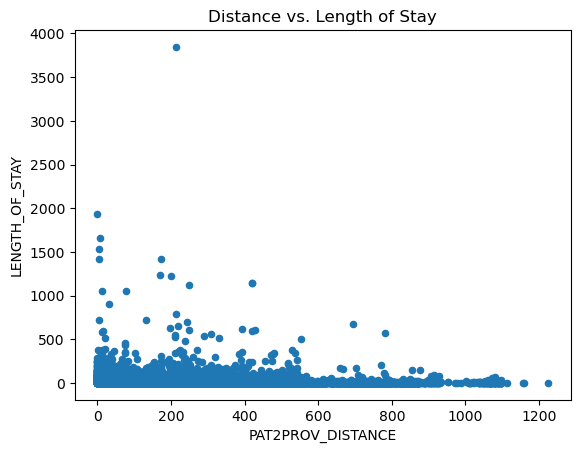

In [12]:
df.plot(kind='scatter',
        x='PAT2PROV_DISTANCE',
        y='LENGTH_OF_STAY',
        title='Distance vs. Length of Stay')
plt.show()

## Geographical distribution of patient zip codes

In [13]:
import plotly.express as px

# 1. Aggregate counts per zip code
df_counts = df.groupby('PAT_ZIP').size().reset_index(name='count')
df_counts.columns = ['zip_code','count']

# 2. Geocode zip codes to get Latitude and Longitude
nomi = pgeocode.Nominatim('us')
df_counts['latitude'] = df_counts['zip_code'].apply(lambda x: nomi.query_postal_code(x).latitude)
df_counts['longitude'] = df_counts['zip_code'].apply(lambda x: nomi.query_postal_code(x).longitude)

# Drop any rows where the zip code wasn't resolved
df_counts = df_counts.dropna(subset=['latitude', 'longitude'])


In [14]:
# Center coordinates for the geographic center of Texas
texas_center = {"lat": 31.9686, "lon": -99.9018}

# Generate the map
fig = px.scatter_mapbox(
    df_counts, 
    lat="latitude", 
    lon="longitude", 
    size="count",                 # Column determining circle size
    hover_name="zip_code",
    hover_data=["count"],
    zoom=4.2, 
    center=texas_center,     # Locks the map focus onto Texas    
    mapbox_style="carto-positron", # Clean, free-to-use map layer
    title="Texas Zip Code Distribution"
    
)

# Increase maximum bubble size for better visibility
fig.update_traces(marker=dict(sizemin=2.5))

# Display the map
fig.show()

/tmp/ipykernel_20734/16205751.py:5: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


## Geographical distribution of provider zip codes

In [15]:
# 1. Aggregate counts per zip code
df_counts = df.groupby('PROVIDER_ZIP').size().reset_index(name='count')
df_counts.columns = ['zip_code','count']

# 2. Geocode zip codes to get Latitude and Longitude
nomi = pgeocode.Nominatim('us')
df_counts['latitude'] = df_counts['zip_code'].apply(lambda x: nomi.query_postal_code(x).latitude)
df_counts['longitude'] = df_counts['zip_code'].apply(lambda x: nomi.query_postal_code(x).longitude)

# Drop any rows where the zip code wasn't resolved
df_counts = df_counts.dropna(subset=['latitude', 'longitude'])


In [16]:
# Center coordinates for the geographic center of Texas
texas_center = {"lat": 31.9686, "lon": -99.9018}

# Generate the map
fig = px.scatter_mapbox(
    df_counts, 
    lat="latitude", 
    lon="longitude", 
    size="count",                 # Column determining circle size
    hover_name="zip_code",
    hover_data=["count"],
    zoom=4.2, 
    center=texas_center,     # Locks the map focus onto Texas    
    mapbox_style="carto-positron", # Clean, free-to-use map layer
    title="Texas Zip Code Distribution"
    
)

# Increase maximum bubble size for better visibility
fig.update_traces(marker=dict(sizemin=2.5))

# Display the map
fig.show()

/tmp/ipykernel_20734/16205751.py:5: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


## Effect of race on length of stay and patient-to-provider distance

RACE
- 1 = American Indian/Eskimo/Aleut
- 2 = Asian or Pacific Islander
- 3 = Black
- 4 = White
- 5 = Other

PAT_RURAL
- 0 = No
- 1 = Yes

In [17]:
df_count = df[df['SEX_CODE'].isin(['M','F'])].groupby(['PAT_RURAL','RACE','SEX_CODE'])[['PAT2PROV_DISTANCE','LENGTH_OF_STAY']].mean()
df_count['COUNT'] = df.groupby(['PAT_RURAL','RACE','SEX_CODE'])['RECORD_ID'].size()
df_count

PAT2PROV_DISTANCE  LENGTH_OF_STAY   COUNT
PAT_RURAL RACE SEX_CODE                                           
0         1    F                 18.833036        3.722591     602
               M                 18.301116        4.607390     433
          2    F                 15.540692        3.865154    9826
               M                 17.701344        5.105498    5839
          3    F                 17.926563        5.211430   50447
               M                 19.151350        6.646975   31706
          4    F                 22.271194        4.590685  223168
               M                 25.381774        5.531007  155785
          5    F                 20.998564        4.316576   48418
               M                 25.415155        5.577344   32459
1         1    F                 49.149118        4.777778      72
               M                 74.372972        5.890625      64
          2    F                 74.781223        5.107143     168
               M                 76.048603        6.743363     113
          3    F                 59.413931        5.450980    3366
               M                 74.230500        6.994004    2835
          4    F                 61.394293        4.654727   45254
               M                 70.479444        5.624053   34441
          5    F                 76.208859        4.351594    5896
               M                 83.537039        5.474924    4287

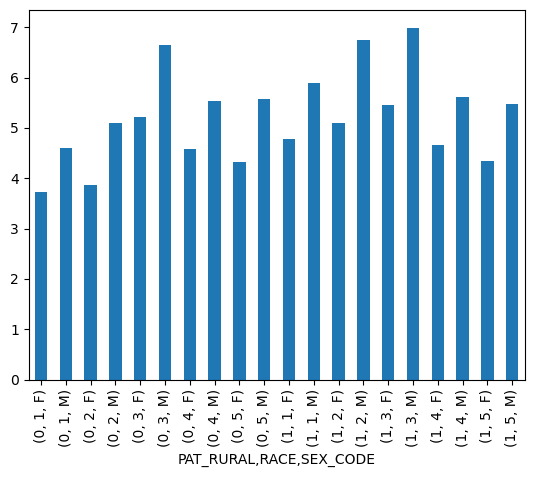

In [18]:
df_count['LENGTH_OF_STAY'].plot(kind='bar')

plt.show()

- Rural patients travel a lot farther to their hospitals.
- Male, rural patients tend to have a longer length of stay.

## Patient age group vs. length of stay

Note that it is patient's age group on the **date of discharge**

In [19]:
df_count = df.groupby('PAT_AGE')[['LENGTH_OF_STAY']].mean()
df_count['COUNT'] = df.groupby('PAT_AGE')[['LENGTH_OF_STAY']].size()
df_count.index.name = 'PAT_AGE_GROUP'
df_count

,LENGTH_OF_STAY,COUNT
PAT_AGE_GROUP,,
0,2.701574,84128
1,16.379245,8923
2,3.925081,8903
3,4.382647,5509
4,5.125092,6811
5,4.947405,7111
6,3.680422,7585
7,3.441100,28540
8,3.365331,36159


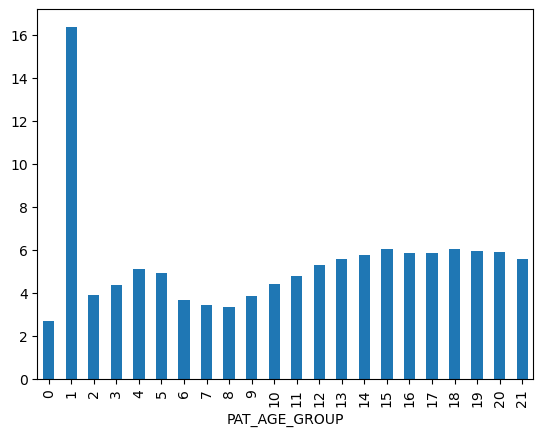

In [20]:
df_count['LENGTH_OF_STAY'].plot(kind='bar')

plt.show()

- Age group (as given on the date of discharge) is a significant predictor of LoS
- Patients in age group 1 (29 to 365 days) have an unusually long
- It is possible they stay so long in the hospital that they move up one age group
- We may wish to discard the data for patients in age group 0 and 1 (under 1 year old) because their age at the point of admission may be different from their age at discharge

In [21]:
df.columns

Index(['RECORD_ID', 'DISCHARGE', 'THCIC_ID', 'TYPE_OF_ADMISSION',
       'SOURCE_OF_ADMISSION', 'PAT_STATE', 'PAT_ZIP', 'PAT_COUNTRY',
       'PAT_COUNTY', 'PUBLIC_HEALTH_REGION', 'PAT_STATUS', 'SEX_CODE', 'RACE',
       'ETHNICITY', 'ADMIT_WEEKDAY', 'LENGTH_OF_STAY', 'PAT_AGE',
       'EMERGENCY_DEPT_FLAG', 'DIAG_CODES_OA', 'CODE_1', 'CODE_2', 'CODE_3',
       'CODE_4', 'CODE_5', 'CODE_6', 'CODE_7', 'CODE_8', 'CODE_9', 'CODE_10',
       'CODE_11', 'CODE_12', 'CODE_13', 'CODE_14', 'CODE_15', 'CODE_16',
       'CODE_17', 'CODE_18', 'CODE_19', 'CODE_20', 'CODE_21', 'CODE_22',
       'PAT_RURAL', 'PROVIDER_ZIP', 'PROVIDER_RURAL', 'PAT2PROV_DISTANCE'],
      dtype='str')

## Type of admission and emergency department flag vs LoS

- 1 = Emergency
- 2 = Urgent
- 3 = Elective
- 4 = Newborn
- 5 = Trauma
- 9 = Information not available

In [22]:
features = ['TYPE_OF_ADMISSION','EMERGENCY_DEPT_FLAG']
df_count = df.groupby(features)[['LENGTH_OF_STAY']].mean()
df_count['COUNT'] = df.groupby(features)[['LENGTH_OF_STAY']].size()
df_count

LENGTH_OF_STAY   COUNT
TYPE_OF_ADMISSION EMERGENCY_DEPT_FLAG                        
1                 N                          5.470658   21846
                  Y                          4.834241  311887
2                 N                          7.263147   57428
                  Y                          4.569340   22707
3                 N                          5.496157  145718
                  Y                          4.138738    6797
4                 N                          3.649489   82163
                  Y                         14.865672     134
5                 N                          5.760000      75
                  Y                          5.987140    4510
9                 N                          4.791091    1302
                  Y                          5.093272     654

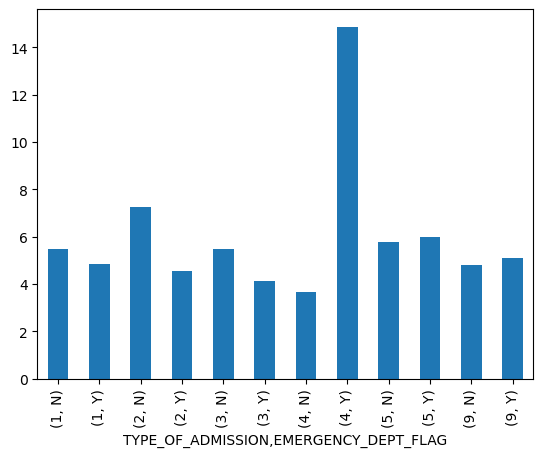

In [23]:
df_count['LENGTH_OF_STAY'].plot(kind='bar')

plt.show()

Newborns in an emergency visit tend to have significantly longer LoS